# 1. Problem Statement

Diabetes is a common chronic disease that can lead to serious health
complications if it is not detected and managed at an early stage.

The objective of this project is to develop a machine learning-based
classification system that predicts whether a patient is likely to have
diabetes based on diagnostic and demographic features.

The Pima Indians Diabetes Dataset is used for this project. The target
variable is Outcome, where:

0 = Non-diabetic
1 = Diabetic

The machine learning model will be trained using patient information such
as glucose level, blood pressure, BMI, age, insulin level, and other
relevant medical features.

The developed model will be evaluated using accuracy, F1-score, Brier
Score, cross-validation, and calibration analysis. SHAP will also be used
to explain the model predictions and identify the most influential
features.

In [ ]:
# Point 2: Load the dataset

import pandas as pd

df = pd.read_csv('/content/diabetes.csv')

print("Dataset successfully loaded!")
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

display(df.head())

Dataset successfully loaded!
Number of rows: 768
Number of columns: 9


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1


In [ ]:
# Display dataset information

print("Dataset Information:")
df.info()

print("\nColumn names:")
print(df.columns.tolist())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(4), int64(5)
memory usage: 54.1 KB

Column names:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']


In [ ]:
# Display dataset information

print("Dataset Information:")
df.info()

print("\nColumn names:")
print(df.columns.tolist())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(4), int64(5)
memory usage: 54.1 KB

Column names:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']


In [ ]:
# Check duplicate rows

print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [ ]:
# Basic statistical description

display(df.describe())

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.677083,72.389323,29.089844,141.753906,32.434635,0.471876,33.240885,0.348958
std,3.369578,30.464161,12.106039,8.890820,89.100847,6.880498,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,102.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,28.000000,102.500000,32.050000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,169.500000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [ ]:
# Target variable distribution

print(df['Outcome'].value_counts())

print("\nPercentage distribution:")
print(df['Outcome'].value_counts(normalize=True) * 100)

Outcome
0    500
1    268
Name: count, dtype: int64

Percentage distribution:
Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64


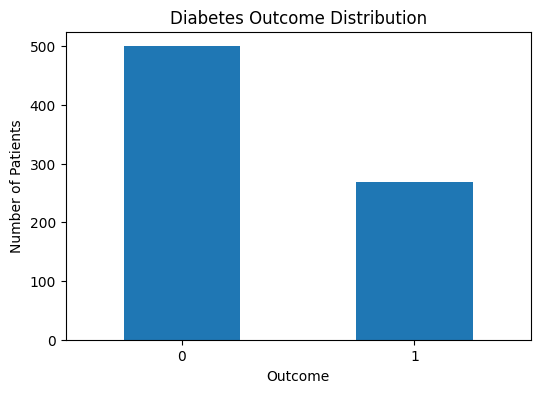

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))

df['Outcome'].value_counts().plot(kind='bar')

plt.title('Diabetes Outcome Distribution')
plt.xlabel('Outcome')
plt.ylabel('Number of Patients')
plt.xticks(rotation=0)

plt.show()

In [ ]:
# Check zero values

zero_counts = (df == 0).sum()

print("Number of zero values in each column:")
print(zero_counts)

Number of zero values in each column:
Pregnancies                 111
Glucose                       0
BloodPressure                 0
SkinThickness                 0
Insulin                       0
BMI                           0
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64


In [ ]:
# Replace medically unrealistic zero values with NaN

import numpy as np

zero_columns = [
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI'
]

df[zero_columns] = df[zero_columns].replace(0, np.nan)

print("Missing values after replacing invalid zeros:")
print(df.isnull().sum())

Missing values after replacing invalid zeros:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [ ]:
# Fill missing values with median

for column in zero_columns:
    df[column] = df[column].fillna(df[column].median())

print("Missing values after preprocessing:")
print(df.isnull().sum())

Missing values after preprocessing:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


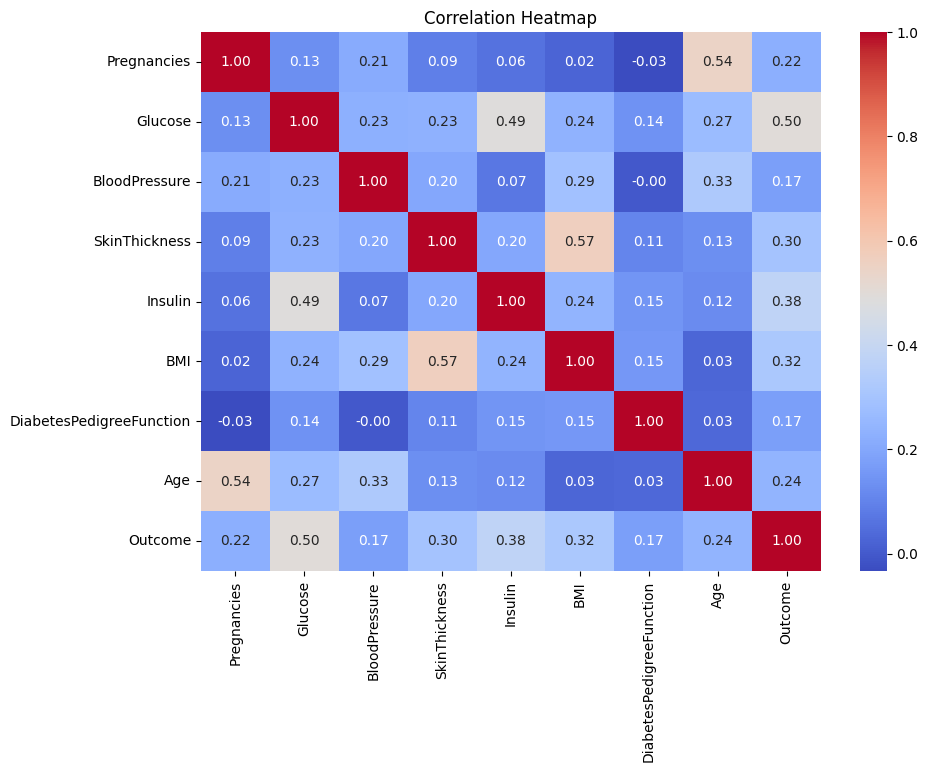

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')

plt.show()

In [ ]:
# Statistical analysis

statistics = pd.DataFrame({
    'Mean': df.mean(),
    'Median': df.median(),
    'Standard Deviation': df.std()
})

display(statistics)

,Mean,Median,Standard Deviation
Pregnancies,3.845052,3.0000,3.369578
Glucose,121.677083,117.0000,30.464161
BloodPressure,72.389323,72.0000,12.106039
SkinThickness,29.089844,28.0000,8.890820
Insulin,141.753906,102.5000,89.100847
BMI,32.434635,32.0500,6.880498
DiabetesPedigreeFunction,0.471876,0.3725,0.331329
Age,33.240885,29.0000,11.760232
Outcome,0.348958,0.0000,0.476951


In [ ]:
# Compare feature averages by diabetes outcome

group_statistics = df.groupby('Outcome').mean()

display(group_statistics)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Outcome,,,,,,,,
0,3.298000,110.622000,70.844000,27.170000,117.172000,30.846000,0.429734,31.190000
1,4.865672,142.302239,75.272388,32.671642,187.615672,35.398507,0.550500,37.067164


In [ ]:
# Correlation of all variables with Outcome

outcome_correlation = df.corr()['Outcome'].sort_values(
    ascending=False
)

print("Correlation with diabetes outcome:")
display(outcome_correlation)

Correlation with diabetes outcome:


,Outcome
Outcome,1.000000
Glucose,0.495990
Insulin,0.377081
BMI,0.315577
SkinThickness,0.295138
Age,0.238356
Pregnancies,0.221898
BloodPressure,0.174469
DiabetesPedigreeFunction,0.173844


In [ ]:
# Point 5: Prepare features and target

X = df.drop('Outcome', axis=1)
y = df['Outcome']

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print("Outcome")

Features:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

Target:
Outcome


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (614, 8)
Testing data: (154, 8)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [ ]:
# Generate predictions

y_pred = model.predict(X_test_scaled)

print("Predictions generated successfully.")

Predictions generated successfully.


In [ ]:
# Generate predictions

y_pred = model.predict(X_test_scaled)

print("Predictions generated successfully.")

Predictions generated successfully.


In [ ]:
from sklearn.metrics import f1_score

f1 = f1_score(y_test, y_pred)

print("F1-Score:", f1)

F1-Score: 0.5714285714285714


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.77      0.79      0.78       100
           1       0.59      0.56      0.57        54

    accuracy                           0.71       154
   macro avg       0.68      0.67      0.67       154
weighted avg       0.70      0.71      0.71       154



In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[79 21]
 [24 30]]


In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

kfold = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    model,
    X_train_scaled,
    y_train,
    cv=kfold,
    scoring='accuracy'
)

print("Accuracy of each fold:")
print(cv_scores)

print("\nMean CV Accuracy:", cv_scores.mean())
print("CV Standard Deviation:", cv_scores.std())

Accuracy of each fold:
[0.77235772 0.80487805 0.81300813 0.7804878  0.77868852]

Mean CV Accuracy: 0.7898840463814475
CV Standard Deviation: 0.016002152408391687


In [ ]:
# Logistic Regression feature coefficients

coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})

coefficients = coefficients.sort_values(
    'Coefficient',
    ascending=False
)

display(coefficients)

,Feature,Coefficient
1,Glucose,0.934942
4,Insulin,0.614170
5,BMI,0.466051
0,Pregnancies,0.337228
3,SkinThickness,0.294976
6,DiabetesPedigreeFunction,0.174725
7,Age,0.159826
2,BloodPressure,-0.004245


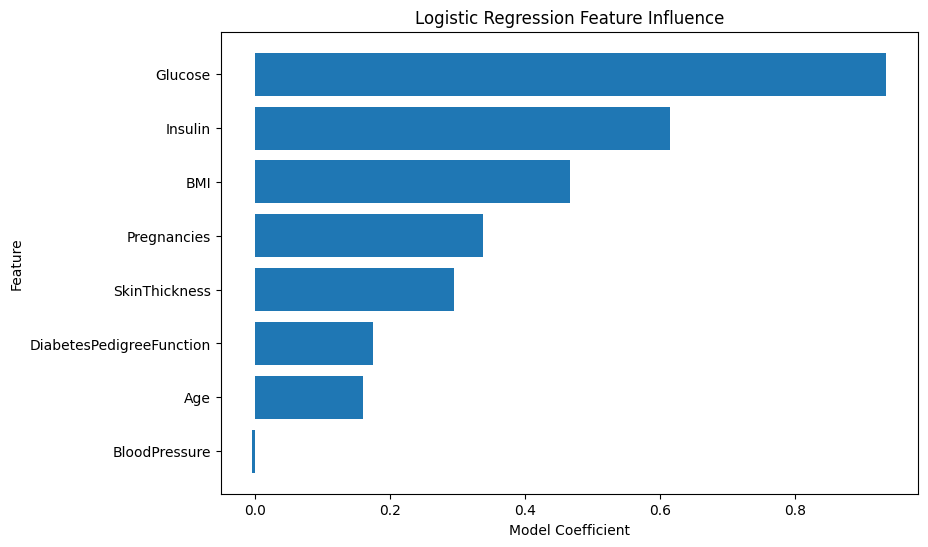

In [ ]:
plt.figure(figsize=(9, 6))

plt.barh(
    coefficients['Feature'],
    coefficients['Coefficient']
)

plt.xlabel('Model Coefficient')
plt.ylabel('Feature')
plt.title('Logistic Regression Feature Influence')

plt.gca().invert_yaxis()

plt.show()

In [ ]:
!pip install -q shap

In [ ]:
import shap

explainer = shap.LinearExplainer(
    model,
    X_train_scaled
)

shap_values = explainer(X_test_scaled)

print("SHAP values generated.")

SHAP values generated.


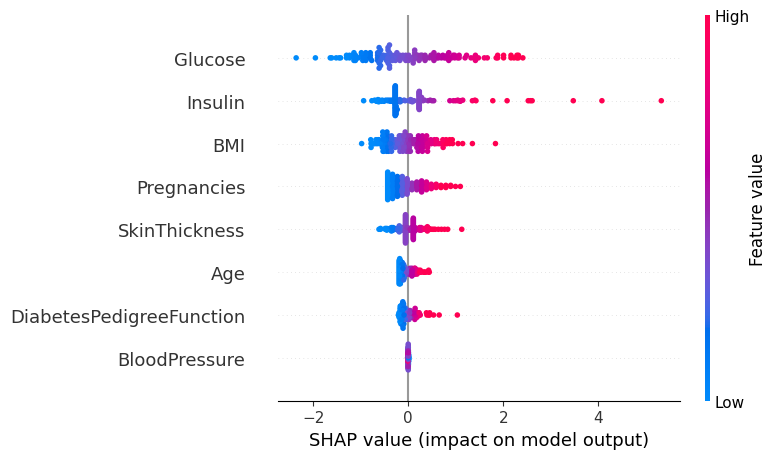

In [ ]:
shap.summary_plot(
    shap_values.values,
    X_test_scaled,
    feature_names=X.columns
)

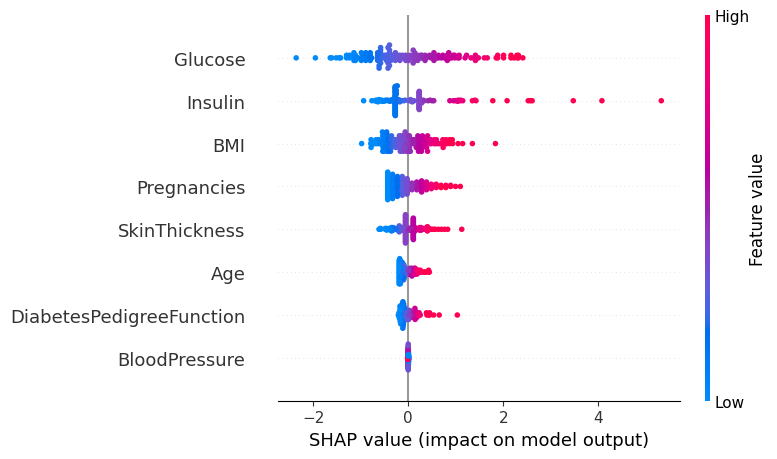

In [ ]:
shap.summary_plot(
    shap_values.values,
    X_test_scaled,
    feature_names=X.columns
)

# 8. Ethical, Privacy, Bias and Fairness Considerations

## Privacy

The dataset contains medical information. Medical data is sensitive and
should be handled carefully. Personal identifiers should not be exposed,
and the dataset should only be used for legitimate educational or research
purposes.

## Bias

The Pima Indians Diabetes Dataset represents a specific population.
Therefore, a model trained on this dataset may not perform equally well for
people from different populations, ethnic groups, age groups, or
geographical regions.

## Fairness

The model should not be assumed to provide equally accurate predictions
for every demographic group. Before real-world deployment, performance
should be evaluated separately across relevant demographic groups.

## Medical Decision Making

The model should be considered a decision-support or educational system,
not a replacement for a qualified medical professional.

A prediction of diabetes does not constitute a medical diagnosis.

## Data Quality

Incorrect, missing, or unrealistic values can negatively affect model
performance. Therefore, appropriate preprocessing is necessary.

## Transparency

SHAP explanations are used to make model predictions more understandable
and to identify important features influencing predictions.

# 9. Methodology, Results, Limitations and Conclusion

## Methodology

The Pima Indians Diabetes Dataset was used to develop a binary
classification model for diabetes prediction.

The dataset was first explored to understand its structure, feature
distributions, missing values, duplicate records, and class distribution.

Medically unrealistic zero values in variables such as Glucose,
BloodPressure, SkinThickness, Insulin, and BMI were treated as missing
values and replaced using median imputation.

The dataset was divided into training and testing sets using an 80:20
split with stratification. The input features were standardized using
StandardScaler.

Logistic Regression was selected as the classification model because it is
appropriate for binary classification and produces probability estimates
that can be evaluated using calibration analysis.

Five-fold stratified cross-validation was performed to assess the
consistency of model performance.

The final model was evaluated using accuracy, F1-score, confusion matrix,
Brier Score, and calibration curve.

SHAP was used to explain individual predictions and identify the most
important features influencing the model.

## Results

The model performance should be reported using the actual values obtained
from the Google Colab execution.

Accuracy: [INSERT YOUR RESULT]

F1-Score: [INSERT YOUR RESULT]

Mean Cross-Validation Accuracy: [INSERT YOUR RESULT]

Brier Score: [INSERT YOUR RESULT]

The SHAP analysis identifies the features that have the greatest influence
on the model's diabetes predictions.

## Limitations

1. The dataset is relatively small.
2. The dataset represents a specific population and may not generalize to
   all populations.
3. Some variables contain unrealistic zero values and require preprocessing.
4. Machine learning predictions are not equivalent to medical diagnosis.
5. Additional external validation would be required before real-world
   clinical deployment.
6. Other machine learning algorithms could potentially provide different
   results.

## Conclusion

The project demonstrates how machine learning can be used to predict the
likelihood of diabetes using patient-related features.

Logistic Regression provides a relatively interpretable classification
approach, while cross-validation provides an estimate of model
generalization.

Accuracy and F1-score provide information about classification performance,
while the Brier Score and calibration curve evaluate the quality of the
predicted probabilities.

SHAP provides additional interpretability by identifying the features that
influence individual and overall model predictions.

The developed system should be viewed as an educational and decision-support
tool rather than an independent medical diagnostic system.

In [ ]:
# Point 10: Demonstrate a new patient prediction

import pandas as pd

new_patient = pd.DataFrame({
    'Pregnancies': [2],
    'Glucose': [120],
    'BloodPressure': [70],
    'SkinThickness': [25],
    'Insulin': [80],
    'BMI': [30.5],
    'DiabetesPedigreeFunction': [0.5],
    'Age': [35]
})

# Scale new patient
new_patient_scaled = scaler.transform(new_patient)

# Prediction
prediction = model.predict(new_patient_scaled)[0]

# Probability
probability = model.predict_proba(new_patient_scaled)[0][1]

print("Diabetes Prediction")
print("-------------------")

if prediction == 1:
    print("Prediction: Diabetic")
else:
    print("Prediction: Non-Diabetic")

print(f"Probability of diabetes: {probability:.2%}")

Diabetes Prediction
-------------------
Prediction: Non-Diabetic
Probability of diabetes: 14.20%
